In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
source_name = "scream"
# source_name = "IMERGv7"
# source_name = "icon_d3hp003"
# source_name = "casesm2_10km_nocumulus"
root_dir = f"/pscratch/sd/w/wcmca1/hackathon/cof_masks/"
# in_dir = f"{root_dir}/{source_name}_cofmasks_hp8_v1.zarr"
in_dir = f"{root_dir}/{source_name}_cofmasks_hp8_v1_stream.zarr"
figdir = f"/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/"
os.makedirs(figdir, exist_ok=True)

# Load the processed dataset
print(f"Loading data from: {in_dir}")

# ds = xr.open_dataset(in_dir)
ds = xr.open_zarr(in_dir, mask_and_scale=False, consolidated=True)
# ds = xr.open_dataset(in_dir, engine='zarr')
ds = ds.pipe(egh.attach_coords)
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/cof_masks//scream_cofmasks_hp8_v1_stream.zarr


<xarray.Dataset> Size: 158GB
Dimensions:                  (time: 3138, cell: 786432)
Coordinates:
  * time                     (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ....
    crs                      int64 8B 0
  * cell                     (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
    lat                      (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                      (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
Data variables: (12/16)
    ar_etc_overlap_mask      (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_isolated_mask         (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mask                  (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mcs_overlap_mask      (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    etc_ar_overlap_mask      (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ...                       ...
    mcs_ar_etc_overlap_mask  (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_ar_overlap_mask      (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_etc_overlap_mask     (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_isolated_mask        (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_mask                 (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    tc_mask                  (time, cell) float32 10GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
Attributes: (12/45)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tc_filtering_threshold:       10%
    threads_per_worker:           2
    thresholds:                   MCS: 20%, AR: 10%, ETC: 5% (2-way), 0% (3-way)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [3]:
ds.chunks

Frozen({'time': (48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 18), 'cell': (786432,)})

In [4]:
ds.crs
# ds.crs.values, ds.crs.attrs

<xarray.DataArray 'crs' ()> Size: 8B
array(0)
Coordinates:
    crs      int64 8B 0
Attributes:
    grid_mapping_name:  healpix
    healpix_nside:      256
    healpix_order:      nest
    _FillValue:         nan

In [5]:
# tm = '2019-08-03T00'
# tm = '2019-08-03T12'
# tm = '2020-08-28T00'
tm = '2020-01-01T00'

# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

print(f"Dataset loaded successfully!")
print(f"Data variables: {list(_ds.data_vars)}")
print(f"Spatial dimensions: {_ds.dims}")

Dataset loaded successfully!
Data variables: ['ar_etc_overlap_mask', 'ar_isolated_mask', 'ar_mask', 'ar_mcs_etc_overlap_mask', 'ar_mcs_overlap_mask', 'etc_ar_overlap_mask', 'etc_isolated_mask', 'etc_mask', 'etc_mcs_ar_overlap_mask', 'etc_mcs_overlap_mask', 'mcs_ar_etc_overlap_mask', 'mcs_ar_overlap_mask', 'mcs_etc_overlap_mask', 'mcs_isolated_mask', 'mcs_mask', 'tc_mask']
Spatial dimensions: FrozenMappingWarningOnValuesAccess({'cell': 786432})


In [6]:
print(ds.mcs_mask.chunks)

((48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 18), (786432,))


In [7]:
np.unique(_ds.etc_mask, return_counts=True)

(array([  0., 183., 188., 189., 190., 191., 192.], dtype=float32),
 array([734143,  22410,   5976,   5971,   5975,   5981,   5976]))

## Visualize all masks

In [8]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12, 
                          show_track_labels=True, track_fontsize=8):
    """
    Plot all 4 feature masks at a single time step with optional track labels.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    - show_track_labels: whether to show track ID labels for ETC and AR features (default True)
    - track_fontsize: font size for track labels (default 8)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add track labels for ETC and AR features if requested
    if show_track_labels:
        # Helper function for circular longitude averaging (handles dateline crossing)
        def circular_lon_mean(lon_values):
            """Calculate circular mean for longitude values to handle dateline crossing."""
            # Convert to radians
            lon_rad = np.deg2rad(lon_values)
            # Calculate circular mean using complex numbers
            mean_complex = np.mean(np.exp(1j * lon_rad))
            # Convert back to degrees and ensure 0-360 range
            mean_lon = np.rad2deg(np.angle(mean_complex))
            if mean_lon < 0:
                mean_lon += 360
            return mean_lon
        
        # Add ETC track labels (green)
        etc_tracks = np.unique(etc_mask.values[etc_mask.values > 0])
        for track_id in etc_tracks:
            track_pixels = (etc_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='green', ha='center', va='center')
        
        # Add AR track labels (darkorange)
        ar_tracks = np.unique(ar_mask.values[ar_mask.values > 0])
        for track_id in ar_tracks:
            track_pixels = (ar_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='darkorange', ha='center', va='center')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

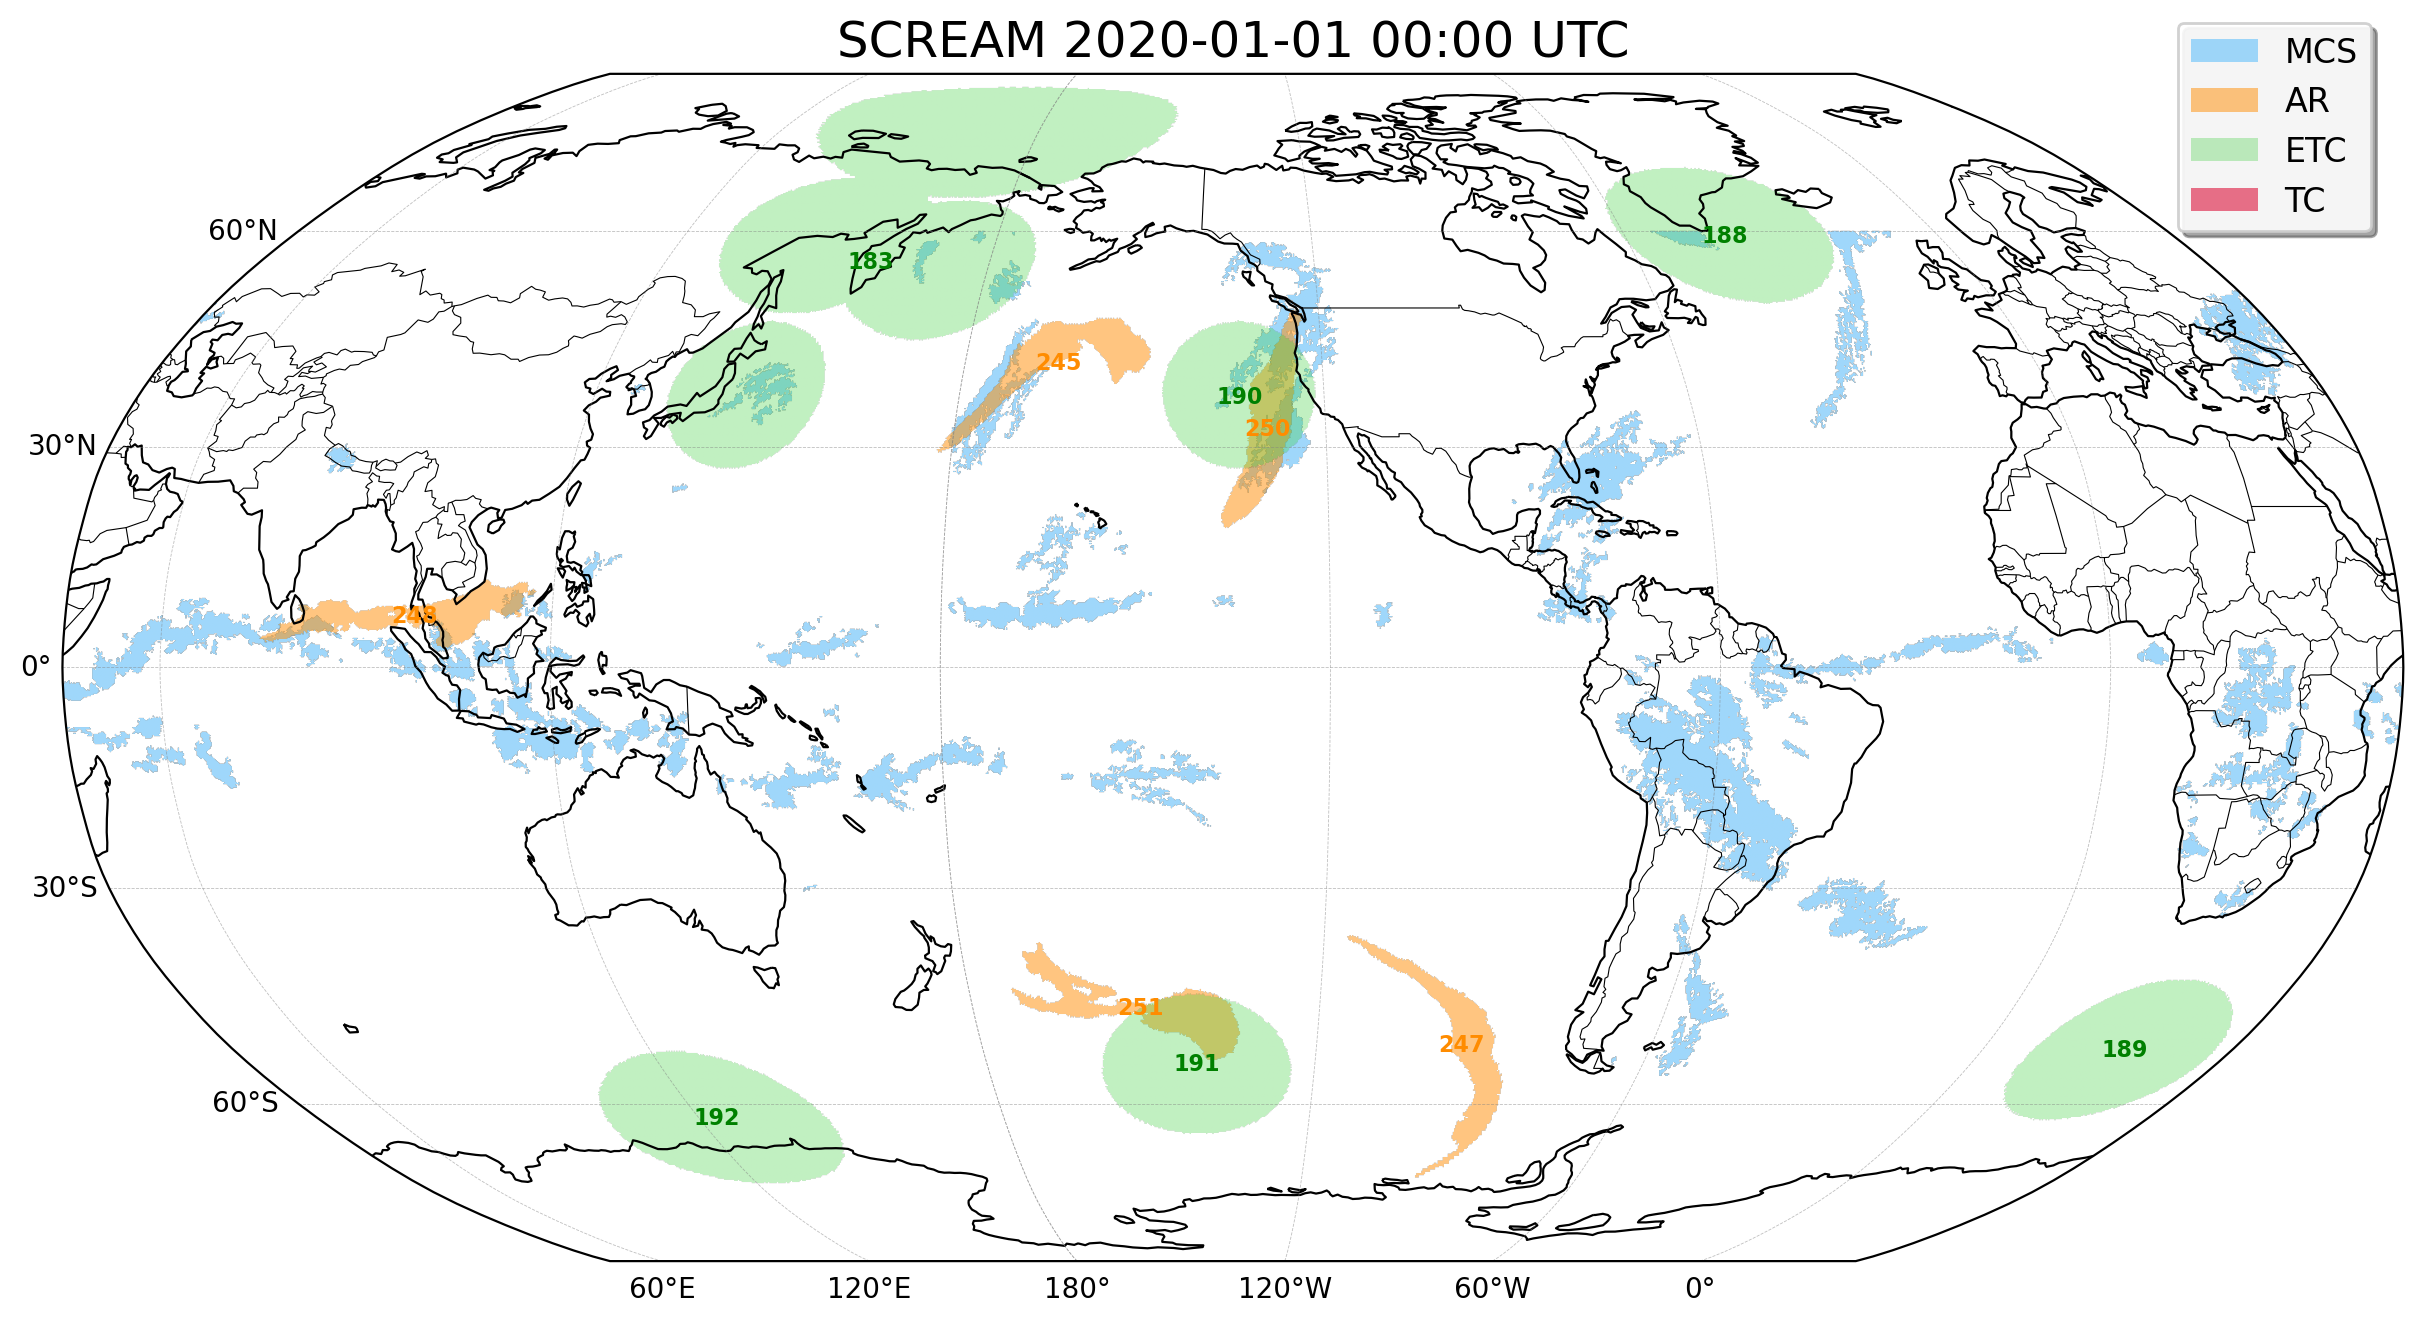

In [9]:
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    # figname=figname,
    dpi=200,
    show_track_labels=True,
    track_fontsize=8
)
plt.show()

## Comprehensive 6-Panel Visualization

Final visualization showing all original features and co-occuring features.

In [10]:
def create_comprehensive_6panel_visualization(ds, 
                                             figname=None,
                                             suptitle=""):
    """
    Create a comprehensive 6-panel visualization (3x2 grid):
    - Top row: All original features (left) and Isolated features (right)
    - Middle and bottom rows: 4 panels showing different overlap types
    
    This version works with overlap masks from zarr files instead of pair lists.
    """
    
    print("🎨 Creating comprehensive 6-panel visualization...")
    
    # Helper function for circular longitude averaging
    def circular_lon_mean(lon_values):
        """Calculate circular mean for longitude values to handle dateline crossing."""
        lon_rad = np.deg2rad(lon_values)
        mean_complex = np.mean(np.exp(1j * lon_rad))
        mean_lon = np.rad2deg(np.angle(mean_complex))
        if mean_lon < 0:
            mean_lon += 360
        return mean_lon
    
    track_fontsize = 10
    mcs_fontsize = 7
    title_fontsize = 12

    # Create GridSpec layout: 3 rows, 2 columns for equal-sized panels
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], width_ratios=[1, 1], 
                          hspace=0.12, wspace=0.05, top=0.9, bottom=0.05, left=0.05, right=0.95)
    
    # Figure suptitle
    fig.suptitle(suptitle, fontsize=title_fontsize*1.3, fontweight='bold', y=0.95)
    
    # Create projection for all axes
    projection = ccrs.Robinson(central_longitude=-135)
    
    # Top row panels
    ax_overview = fig.add_subplot(gs[0, 0], projection=projection)  # All original features
    ax_isolated = fig.add_subplot(gs[0, 1], projection=projection)  # Isolated features
    
    # Bottom panels: 2x2 grid for 4 overlap types (equal size)
    ax_mcs_ar = fig.add_subplot(gs[1, 0], projection=projection)
    ax_ar_etc = fig.add_subplot(gs[1, 1], projection=projection)
    ax_mcs_etc = fig.add_subplot(gs[2, 0], projection=projection)
    ax_3way = fig.add_subplot(gs[2, 1], projection=projection)
    
    # Configure all axes
    all_axes = [ax_overview, ax_isolated, ax_mcs_ar, ax_ar_etc, ax_mcs_etc, ax_3way]
    for ax in all_axes:
        ax.set_global()
        ax.add_feature(cf.COASTLINE, linewidth=0.5)
    
    # ==== TOP LEFT PANEL: ALL ORIGINAL FEATURES ====
    print("  📍 Creating overview panel with all features...")
    
    # Create binary masks for visualization
    mcs_binary = (ds.mcs_mask > 0).astype(float)
    ar_binary = (ds.ar_mask > 0).astype(float)
    etc_binary = (ds.etc_mask > 0).astype(float)
    tc_binary = (ds.tc_mask > 0).astype(float)
    
    # Define colors and alphas
    overview_colors = {'mcs': 'lightblue', 'ar': 'orange', 'etc': 'limegreen', 'tc': 'red'}
    overview_alphas = {'mcs': 0.6, 'ar': 0.4, 'etc': 0.3, 'tc': 0.5}
    
    # Plot features in order (MCS first, then overlays)
    if np.any(mcs_binary > 0):
        egh.healpix_show(mcs_binary.where(mcs_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]),
                        alpha=overview_alphas['mcs'], vmin=0.5, vmax=1.5)
    
    if np.any(ar_binary > 0):
        egh.healpix_show(ar_binary.where(ar_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]),
                        alpha=overview_alphas['ar'], vmin=0.5, vmax=1.5)
    
    if np.any(etc_binary > 0):
        egh.healpix_show(etc_binary.where(etc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]),
                        alpha=overview_alphas['etc'], vmin=0.5, vmax=1.5)
    
    if np.any(tc_binary > 0):
        egh.healpix_show(tc_binary.where(tc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['tc']]),
                        alpha=overview_alphas['tc'], vmin=0.5, vmax=1.5)
    
    # Add track labels for AR and ETC (following cell 6 style)
    # track_fontsize = 10
    
    # AR track labels (orange)
    ar_tracks = np.unique(ds.ar_mask.values[ds.ar_mask.values > 0])
    for track_id in ar_tracks:
        track_pixels = (ds.ar_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='darkorange', ha='center', va='center')
    
    # ETC track labels (green)
    etc_tracks = np.unique(ds.etc_mask.values[ds.etc_mask.values > 0])
    for track_id in etc_tracks:
        track_pixels = (ds.etc_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='green', ha='center', va='center')
    
    ax_overview.set_title(f"All Original Features",
                         fontsize=title_fontsize, fontweight='bold', color='black')
    
    # ==== TOP RIGHT PANEL: ISOLATED FEATURES ====
    print("  🔍 Creating isolated features panel...")
    
    # Plot isolated masks with same style as overview panel
    if np.any(ds.mcs_isolated_mask > 0):
        egh.healpix_show(ds.mcs_isolated_mask.where(ds.mcs_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]),
                        alpha=overview_alphas['mcs'], vmin=0.5, vmax=1.5)
    
    if np.any(ds.ar_isolated_mask > 0):
        egh.healpix_show(ds.ar_isolated_mask.where(ds.ar_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]),
                        alpha=overview_alphas['ar'], vmin=0.5, vmax=1.5)
    
    if np.any(ds.etc_isolated_mask > 0):
        egh.healpix_show(ds.etc_isolated_mask.where(ds.etc_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]),
                        alpha=overview_alphas['etc'], vmin=0.5, vmax=1.5)
    
    # Add track labels for isolated AR and ETC
    # AR isolated track labels (orange)
    ar_isolated_tracks = np.unique(ds.ar_isolated_mask.values[ds.ar_isolated_mask.values > 0])
    for track_id in ar_isolated_tracks:
        track_pixels = (ds.ar_isolated_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_isolated.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='darkorange', ha='center', va='center')
    
    # ETC isolated track labels (green)
    etc_isolated_tracks = np.unique(ds.etc_isolated_mask.values[ds.etc_isolated_mask.values > 0])
    for track_id in etc_isolated_tracks:
        track_pixels = (ds.etc_isolated_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_isolated.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='green', ha='center', va='center')
    
    # Count isolated features
    n_mcs_isolated = len(np.unique(ds.mcs_isolated_mask.values[ds.mcs_isolated_mask.values > 0]))
    n_ar_isolated = len(ar_isolated_tracks)
    n_etc_isolated = len(etc_isolated_tracks)
    
    ax_isolated.set_title(f"Isolated Features\nMCS: {n_mcs_isolated}, AR: {n_ar_isolated}, ETC: {n_etc_isolated}",
                         fontsize=title_fontsize, fontweight='bold', color='purple')
    
    # ==== BOTTOM PANELS: OVERLAP ANALYSIS ====
    print("  📊 Creating overlap analysis panels...")
    
    # Extract track numbers directly from overlap masks
    # Panel 1: MCS-AR 2-way overlaps
    mcs_ar_overlap_tracks = np.unique(ds.mcs_ar_overlap_mask.values[ds.mcs_ar_overlap_mask.values > 0])
    ar_mcs_overlap_tracks = np.unique(ds.ar_mcs_overlap_mask.values[ds.ar_mcs_overlap_mask.values > 0])
    
    # Plot MCS-AR overlap masks
    if len(mcs_ar_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_ar_overlap_mask.where(ds.mcs_ar_overlap_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_mcs_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_mcs_overlap_mask.where(ds.ar_mcs_overlap_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    
    # Add track labels for MCS-AR overlaps
    for track_id in mcs_ar_overlap_tracks:
        track_pixels = (ds.mcs_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_mcs_overlap_tracks:
        track_pixels = (ds.ar_mcs_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    ax_mcs_ar.set_title(f"MCS-AR 2-Way\nMCS: {len(mcs_ar_overlap_tracks)}, AR: {len(ar_mcs_overlap_tracks)}",
                       fontsize=title_fontsize, fontweight='bold', color='blue')
    
    # Panel 2: AR-ETC 2-way overlaps
    ar_etc_overlap_tracks = np.unique(ds.ar_etc_overlap_mask.values[ds.ar_etc_overlap_mask.values > 0])
    etc_ar_overlap_tracks = np.unique(ds.etc_ar_overlap_mask.values[ds.etc_ar_overlap_mask.values > 0])
    
    # Plot AR-ETC overlap masks
    if len(ar_etc_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_etc_overlap_mask.where(ds.ar_etc_overlap_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_ar_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_ar_overlap_mask.where(ds.etc_ar_overlap_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels for AR-ETC overlaps
    for track_id in ar_etc_overlap_tracks:
        track_pixels = (ds.ar_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_ar_overlap_tracks:
        track_pixels = (ds.etc_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_ar_etc.set_title(f"AR-ETC 2-Way\nAR: {len(ar_etc_overlap_tracks)}, ETC: {len(etc_ar_overlap_tracks)}",
                       fontsize=title_fontsize, fontweight='bold', color='darkorange')
    
    # Panel 3: MCS-ETC 2-way overlaps
    mcs_etc_overlap_tracks = np.unique(ds.mcs_etc_overlap_mask.values[ds.mcs_etc_overlap_mask.values > 0])
    etc_mcs_overlap_tracks = np.unique(ds.etc_mcs_overlap_mask.values[ds.etc_mcs_overlap_mask.values > 0])
    
    # Plot MCS-ETC overlap masks
    if len(mcs_etc_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_etc_overlap_mask.where(ds.mcs_etc_overlap_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(etc_mcs_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_mcs_overlap_mask.where(ds.etc_mcs_overlap_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels for MCS-ETC overlaps
    for track_id in mcs_etc_overlap_tracks:
        track_pixels = (ds.mcs_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in etc_mcs_overlap_tracks:
        track_pixels = (ds.etc_mcs_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_mcs_etc.set_title(f"MCS-ETC 2-Way\nMCS: {len(mcs_etc_overlap_tracks)}, ETC: {len(etc_mcs_overlap_tracks)}",
                        fontsize=title_fontsize, fontweight='bold', color='limegreen')
    
    # Panel 4: 3-way overlaps
    mcs_3way_overlap_tracks = np.unique(ds.mcs_ar_etc_overlap_mask.values[ds.mcs_ar_etc_overlap_mask.values > 0])
    ar_3way_overlap_tracks = np.unique(ds.ar_mcs_etc_overlap_mask.values[ds.ar_mcs_etc_overlap_mask.values > 0])
    etc_3way_overlap_tracks = np.unique(ds.etc_mcs_ar_overlap_mask.values[ds.etc_mcs_ar_overlap_mask.values > 0])
    
    # Plot 3-way overlap masks
    if len(mcs_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_ar_etc_overlap_mask.where(ds.mcs_ar_etc_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_mcs_etc_overlap_mask.where(ds.ar_mcs_etc_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_mcs_ar_overlap_mask.where(ds.etc_mcs_ar_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)
    
    # Add track labels for 3-way overlaps
    for track_id in mcs_3way_overlap_tracks:
        track_pixels = (ds.mcs_ar_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_3way_overlap_tracks:
        track_pixels = (ds.ar_mcs_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_3way_overlap_tracks:
        track_pixels = (ds.etc_mcs_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_3way.set_title(f"3-Way Overlaps\nMCS: {len(mcs_3way_overlap_tracks)}, AR: {len(ar_3way_overlap_tracks)}, ETC: {len(etc_3way_overlap_tracks)}",
                     fontsize=title_fontsize, fontweight='bold', color='red')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=overview_colors['mcs'], alpha=overview_alphas['mcs'], label='MCS'),
        Patch(facecolor=overview_colors['ar'], alpha=overview_alphas['ar'], label='AR'),
        Patch(facecolor=overview_colors['etc'], alpha=overview_alphas['etc'], label='ETC'),
        Patch(facecolor=overview_colors['tc'], alpha=overview_alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.95, 0.95), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=False, shadow=False)
    
    # Save figure
    if figname is not None:
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f"✅ Comprehensive 6-panel visualization saved: {figname}")
    
    return fig

print("✅ create_comprehensive_6panel_visualization() function defined")

✅ create_comprehensive_6panel_visualization() function defined


🚀 CREATING COMPREHENSIVE 6-PANEL VISUALIZATION
🎨 Creating comprehensive 6-panel visualization...
  📍 Creating overview panel with all features...
  🔍 Creating isolated features panel...
  🔍 Creating isolated features panel...
  📊 Creating overlap analysis panels...
  📊 Creating overlap analysis panels...
✅ Comprehensive 6-panel visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_cofmasks_6panel_20200101_0000.png
✅ Comprehensive 6-panel visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_cofmasks_6panel_20200101_0000.png


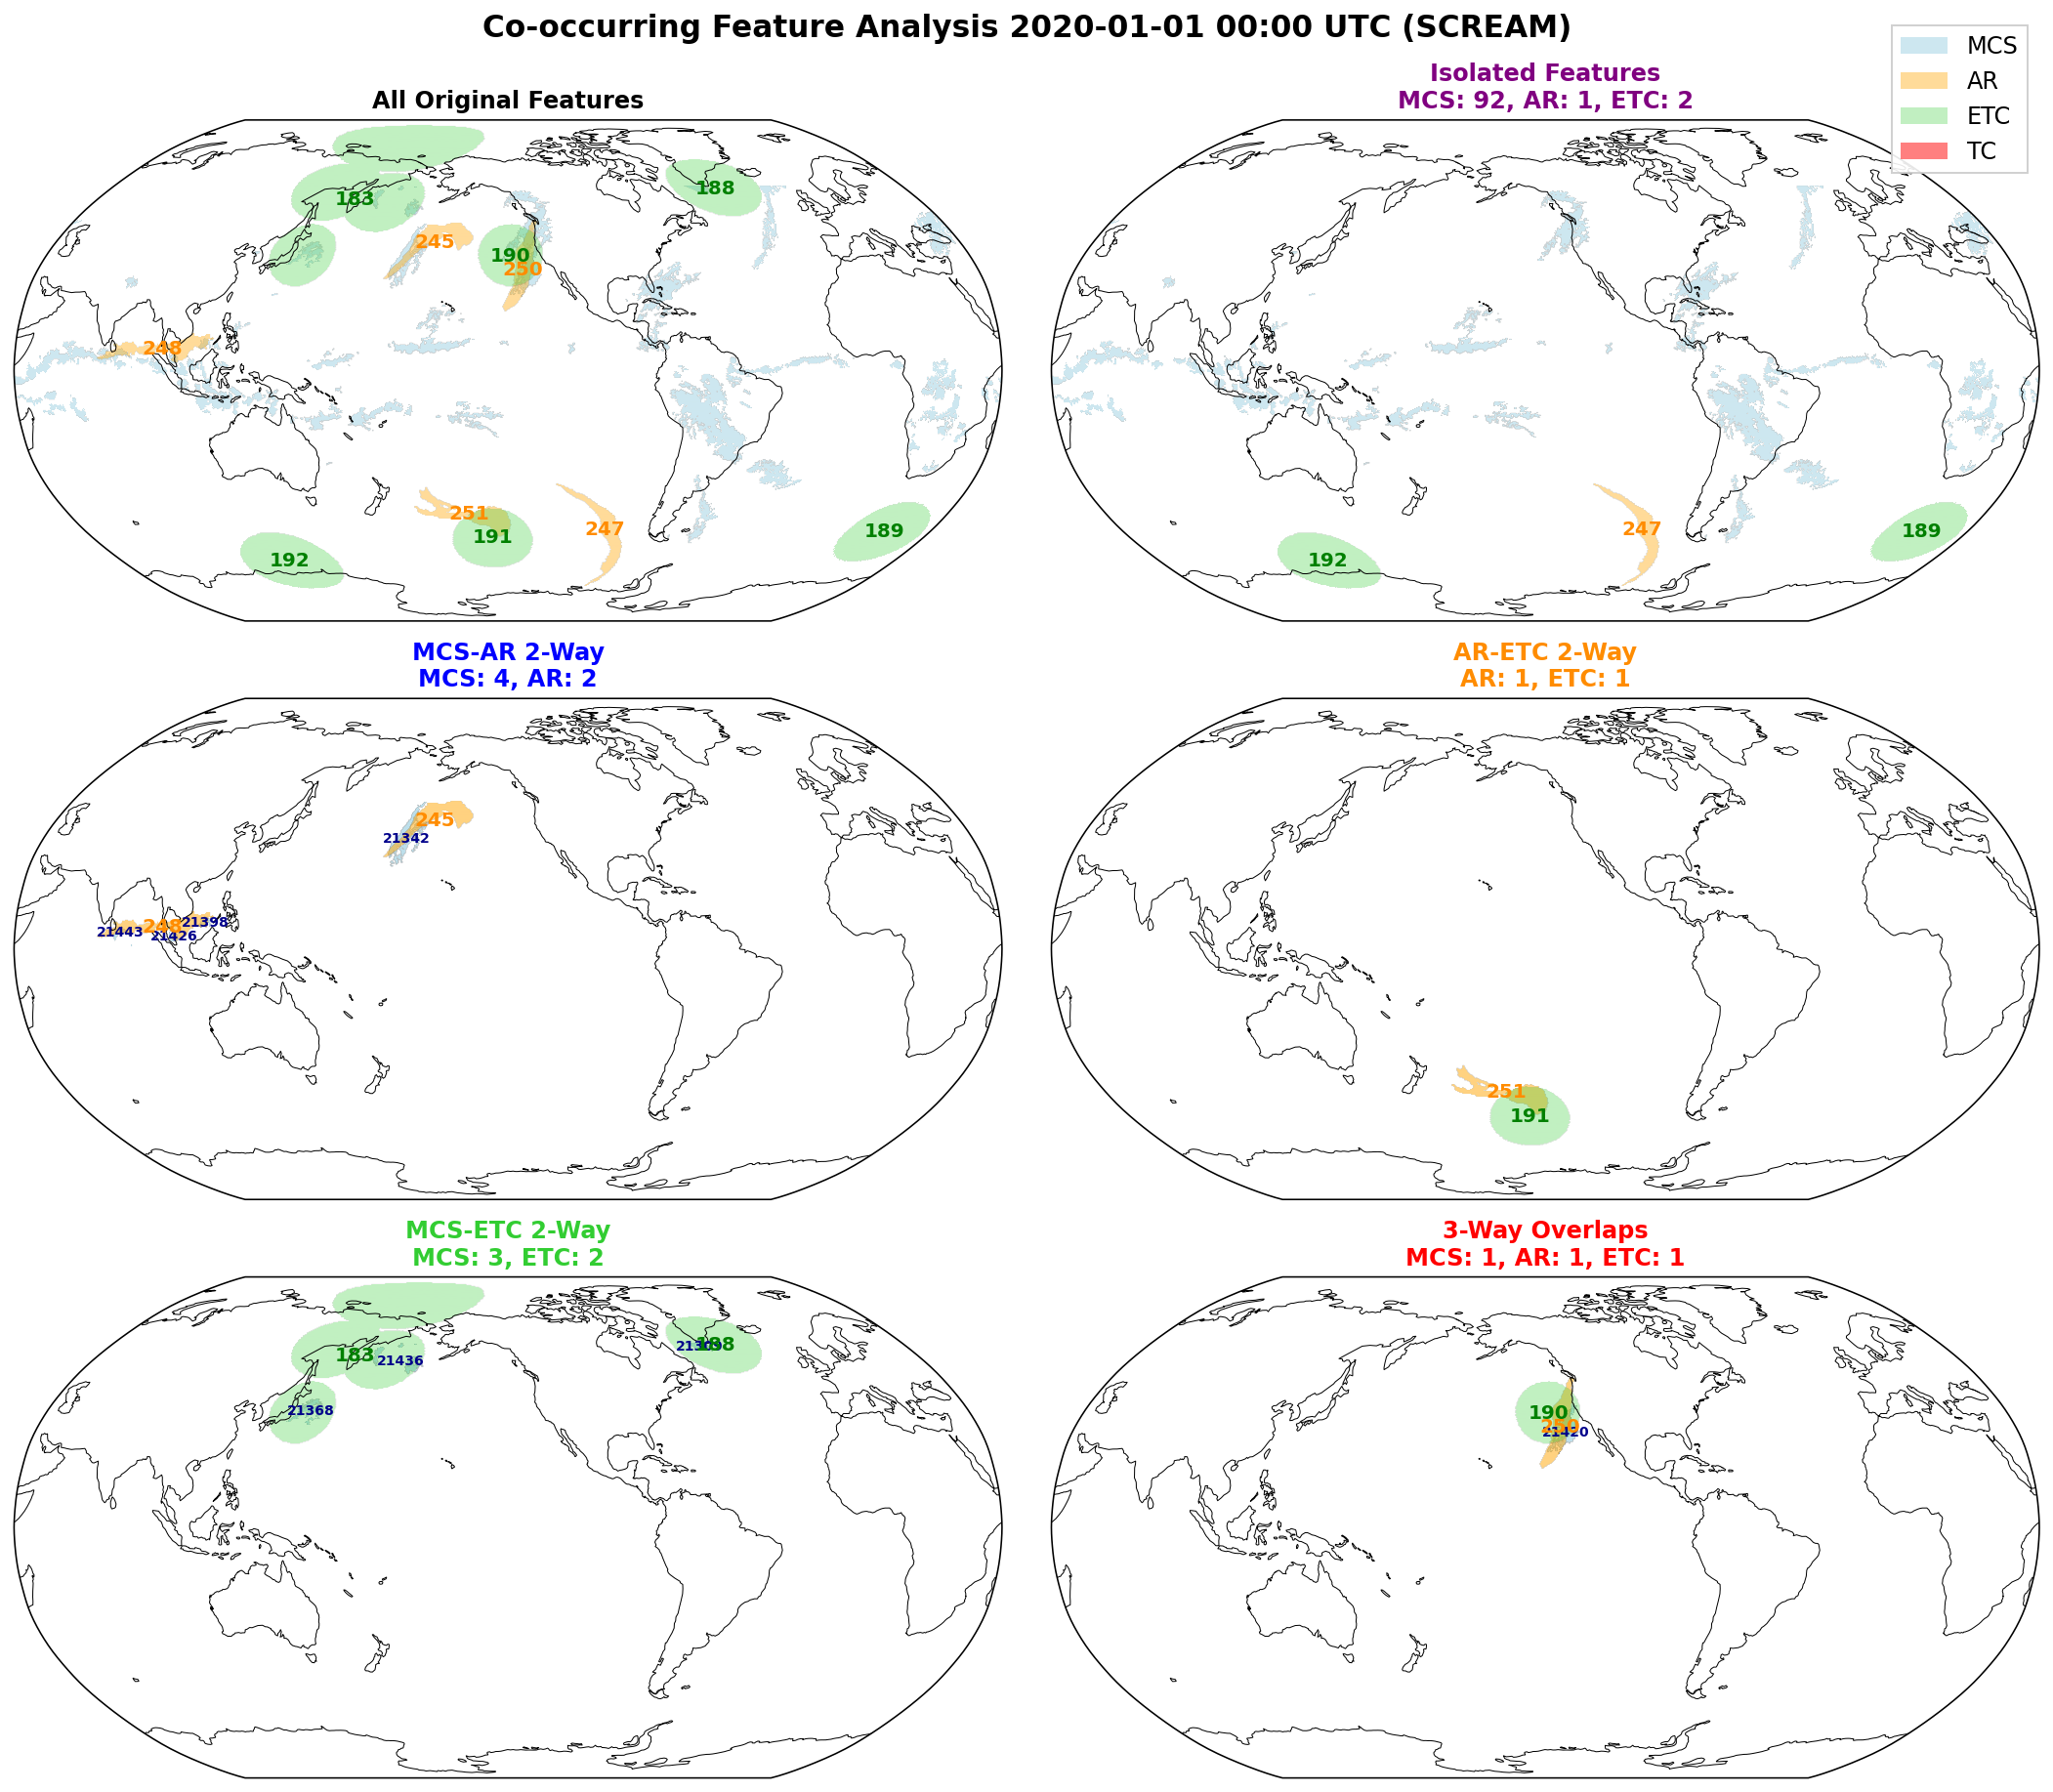

In [11]:
# CREATE COMPREHENSIVE 6-PANEL VISUALIZATION
print("🚀 CREATING COMPREHENSIVE 6-PANEL VISUALIZATION")
print("="*55)

time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
datetime_string = _time.dt.strftime('%Y%m%d_%H%M').item()
suptitle = f"Co-occurring Feature Analysis {time_label} ({source_name.upper()})"
figname = f"{figdir}{source_name}_cofmasks_6panel_{datetime_string}.png"

# Call the comprehensive visualization function
fig_6panel = create_comprehensive_6panel_visualization(
    ds=_ds,
    figname=figname,
    suptitle=suptitle,
)

In [12]:
def plot_6panel_horizontal(ds, figname=None, suptitle=""):
    """
    Create a comprehensive 6-panel visualization (2x3 grid):
    - Row 0: All original features, MCS-AR overlaps, AR-ETC overlaps
    - Row 1: Isolated features, MCS-ETC overlaps, 3-way overlaps
    
    This version works with overlap masks from zarr files instead of pair lists.
    """
    
    print("🎨 Creating comprehensive 6-panel horizontal visualization...")
    
    # Helper function for circular longitude averaging
    def circular_lon_mean(lon_values):
        """Calculate circular mean for longitude values to handle dateline crossing."""
        lon_rad = np.deg2rad(lon_values)
        mean_complex = np.mean(np.exp(1j * lon_rad))
        mean_lon = np.rad2deg(np.angle(mean_complex))
        if mean_lon < 0:
            mean_lon += 360
        return mean_lon
    
    track_fontsize = 10
    mcs_fontsize = 7
    title_fontsize = 12
    legend_fontsize = 12

    # Create GridSpec layout: 2 rows, 3 columns for equal-sized panels
    fig = plt.figure(figsize=(20, 8))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1], 
                          hspace=0.14, wspace=0.05, top=0.85, bottom=0.05, left=0.05, right=0.95)
    
    # Figure suptitle
    fig.suptitle(suptitle, fontsize=title_fontsize*1.3, fontweight='bold', y=0.95)
    
    # Create projection for all axes
    projection = ccrs.Robinson(central_longitude=-135)
    
    # Define all panel positions
    ax_overview = fig.add_subplot(gs[0, 0], projection=projection)    # All original features
    ax_mcs_ar = fig.add_subplot(gs[0, 1], projection=projection)      # MCS-AR overlaps
    ax_ar_etc = fig.add_subplot(gs[0, 2], projection=projection)      # AR-ETC overlaps
    ax_isolated = fig.add_subplot(gs[1, 0], projection=projection)    # Isolated features
    ax_mcs_etc = fig.add_subplot(gs[1, 1], projection=projection)     # MCS-ETC overlaps
    ax_3way = fig.add_subplot(gs[1, 2], projection=projection)        # 3-way overlaps
    
    # Configure all axes
    all_axes = [ax_overview, ax_mcs_ar, ax_ar_etc, ax_isolated, ax_mcs_etc, ax_3way]
    for ax in all_axes:
        ax.set_global()
        ax.add_feature(cf.COASTLINE, linewidth=0.5)
    
    # ==== ROW 0, COL 0: ALL ORIGINAL FEATURES ====
    print("  📍 Creating overview panel with all features...")
    
    # Create binary masks for visualization
    mcs_binary = (ds.mcs_mask > 0).astype(float)
    ar_binary = (ds.ar_mask > 0).astype(float)
    etc_binary = (ds.etc_mask > 0).astype(float)
    tc_binary = (ds.tc_mask > 0).astype(float)
    
    # Define colors and alphas
    overview_colors = {'mcs': 'lightblue', 'ar': 'orange', 'etc': 'limegreen', 'tc': 'red'}
    overview_alphas = {'mcs': 0.6, 'ar': 0.4, 'etc': 0.3, 'tc': 0.5}
    
    # Plot features in order (MCS first, then overlays)
    if np.any(mcs_binary > 0):
        egh.healpix_show(mcs_binary.where(mcs_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]),
                        alpha=overview_alphas['mcs'], vmin=0.5, vmax=1.5)
    
    if np.any(ar_binary > 0):
        egh.healpix_show(ar_binary.where(ar_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]),
                        alpha=overview_alphas['ar'], vmin=0.5, vmax=1.5)
    
    if np.any(etc_binary > 0):
        egh.healpix_show(etc_binary.where(etc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]),
                        alpha=overview_alphas['etc'], vmin=0.5, vmax=1.5)
    
    if np.any(tc_binary > 0):
        egh.healpix_show(tc_binary.where(tc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['tc']]),
                        alpha=overview_alphas['tc'], vmin=0.5, vmax=1.5)
    
    # Add track labels for AR and ETC
    # AR track labels (orange)
    ar_tracks = np.unique(ds.ar_mask.values[ds.ar_mask.values > 0])
    for track_id in ar_tracks:
        track_pixels = (ds.ar_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='darkorange', ha='center', va='center')
    
    # ETC track labels (green)
    etc_tracks = np.unique(ds.etc_mask.values[ds.etc_mask.values > 0])
    for track_id in etc_tracks:
        track_pixels = (ds.etc_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='green', ha='center', va='center')
    
    ax_overview.set_title(f"All Original Features",
                         fontsize=title_fontsize, fontweight='bold', color='black')
    
    # ==== ROW 1, COL 0: ISOLATED FEATURES ====
    print("  🔍 Creating isolated features panel...")
    
    # Plot isolated masks with same style as overview panel
    if np.any(ds.mcs_isolated_mask > 0):
        egh.healpix_show(ds.mcs_isolated_mask.where(ds.mcs_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]),
                        alpha=overview_alphas['mcs'], vmin=0.5, vmax=1.5)
    
    if np.any(ds.ar_isolated_mask > 0):
        egh.healpix_show(ds.ar_isolated_mask.where(ds.ar_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]),
                        alpha=overview_alphas['ar'], vmin=0.5, vmax=1.5)
    
    if np.any(ds.etc_isolated_mask > 0):
        egh.healpix_show(ds.etc_isolated_mask.where(ds.etc_isolated_mask > 0), ax=ax_isolated,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]),
                        alpha=overview_alphas['etc'], vmin=0.5, vmax=1.5)
    
    # Add track labels for isolated AR and ETC
    # AR isolated track labels (orange)
    ar_isolated_tracks = np.unique(ds.ar_isolated_mask.values[ds.ar_isolated_mask.values > 0])
    for track_id in ar_isolated_tracks:
        track_pixels = (ds.ar_isolated_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_isolated.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='darkorange', ha='center', va='center')
    
    # ETC isolated track labels (green)
    etc_isolated_tracks = np.unique(ds.etc_isolated_mask.values[ds.etc_isolated_mask.values > 0])
    for track_id in etc_isolated_tracks:
        track_pixels = (ds.etc_isolated_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_isolated.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='green', ha='center', va='center')
    
    # Count isolated features
    n_mcs_isolated = len(np.unique(ds.mcs_isolated_mask.values[ds.mcs_isolated_mask.values > 0]))
    n_ar_isolated = len(ar_isolated_tracks)
    n_etc_isolated = len(etc_isolated_tracks)
    
    ax_isolated.set_title(f"Isolated Features\nMCS: {n_mcs_isolated}, AR: {n_ar_isolated}, ETC: {n_etc_isolated}",
                         fontsize=title_fontsize, fontweight='bold', color='purple')
    
    # ==== ROW 0, COL 1: MCS-AR 2-WAY OVERLAPS ====
    print("  📊 Creating MCS-AR overlap panel...")
    
    mcs_ar_overlap_tracks = np.unique(ds.mcs_ar_overlap_mask.values[ds.mcs_ar_overlap_mask.values > 0])
    ar_mcs_overlap_tracks = np.unique(ds.ar_mcs_overlap_mask.values[ds.ar_mcs_overlap_mask.values > 0])
    
    # Plot MCS-AR overlap masks
    if len(mcs_ar_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_ar_overlap_mask.where(ds.mcs_ar_overlap_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_mcs_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_mcs_overlap_mask.where(ds.ar_mcs_overlap_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    
    # Add track labels for MCS-AR overlaps
    for track_id in mcs_ar_overlap_tracks:
        track_pixels = (ds.mcs_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_mcs_overlap_tracks:
        track_pixels = (ds.ar_mcs_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    ax_mcs_ar.set_title(f"MCS-AR 2-Way\nMCS: {len(mcs_ar_overlap_tracks)}, AR: {len(ar_mcs_overlap_tracks)}",
                       fontsize=title_fontsize, fontweight='bold', color='blue')
    
    # ==== ROW 0, COL 2: AR-ETC 2-WAY OVERLAPS ====
    print("  📊 Creating AR-ETC overlap panel...")
    
    ar_etc_overlap_tracks = np.unique(ds.ar_etc_overlap_mask.values[ds.ar_etc_overlap_mask.values > 0])
    etc_ar_overlap_tracks = np.unique(ds.etc_ar_overlap_mask.values[ds.etc_ar_overlap_mask.values > 0])
    
    # Plot AR-ETC overlap masks
    if len(ar_etc_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_etc_overlap_mask.where(ds.ar_etc_overlap_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_ar_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_ar_overlap_mask.where(ds.etc_ar_overlap_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels for AR-ETC overlaps
    for track_id in ar_etc_overlap_tracks:
        track_pixels = (ds.ar_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_ar_overlap_tracks:
        track_pixels = (ds.etc_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_ar_etc.set_title(f"AR-ETC 2-Way\nAR: {len(ar_etc_overlap_tracks)}, ETC: {len(etc_ar_overlap_tracks)}",
                       fontsize=title_fontsize, fontweight='bold', color='darkorange')
    
    # ==== ROW 1, COL 1: MCS-ETC 2-WAY OVERLAPS ====
    print("  📊 Creating MCS-ETC overlap panel...")
    
    mcs_etc_overlap_tracks = np.unique(ds.mcs_etc_overlap_mask.values[ds.mcs_etc_overlap_mask.values > 0])
    etc_mcs_overlap_tracks = np.unique(ds.etc_mcs_overlap_mask.values[ds.etc_mcs_overlap_mask.values > 0])
    
    # Plot MCS-ETC overlap masks
    if len(mcs_etc_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_etc_overlap_mask.where(ds.mcs_etc_overlap_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(etc_mcs_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_mcs_overlap_mask.where(ds.etc_mcs_overlap_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels for MCS-ETC overlaps
    for track_id in mcs_etc_overlap_tracks:
        track_pixels = (ds.mcs_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in etc_mcs_overlap_tracks:
        track_pixels = (ds.etc_mcs_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_mcs_etc.set_title(f"MCS-ETC 2-Way\nMCS: {len(mcs_etc_overlap_tracks)}, ETC: {len(etc_mcs_overlap_tracks)}",
                        fontsize=title_fontsize, fontweight='bold', color='limegreen')
    
    # ==== ROW 1, COL 2: 3-WAY OVERLAPS ====
    print("  📊 Creating 3-way overlap panel...")
    
    mcs_3way_overlap_tracks = np.unique(ds.mcs_ar_etc_overlap_mask.values[ds.mcs_ar_etc_overlap_mask.values > 0])
    ar_3way_overlap_tracks = np.unique(ds.ar_mcs_etc_overlap_mask.values[ds.ar_mcs_etc_overlap_mask.values > 0])
    etc_3way_overlap_tracks = np.unique(ds.etc_mcs_ar_overlap_mask.values[ds.etc_mcs_ar_overlap_mask.values > 0])
    
    # Plot 3-way overlap masks
    if len(mcs_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.mcs_ar_etc_overlap_mask.where(ds.mcs_ar_etc_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.ar_mcs_etc_overlap_mask.where(ds.ar_mcs_etc_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_3way_overlap_tracks) > 0:
        egh.healpix_show(ds.etc_mcs_ar_overlap_mask.where(ds.etc_mcs_ar_overlap_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)
    
    # Add track labels for 3-way overlaps
    for track_id in mcs_3way_overlap_tracks:
        track_pixels = (ds.mcs_ar_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_3way_overlap_tracks:
        track_pixels = (ds.ar_mcs_etc_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_3way_overlap_tracks:
        track_pixels = (ds.etc_mcs_ar_overlap_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_3way.set_title(f"3-Way Overlaps\nMCS: {len(mcs_3way_overlap_tracks)}, AR: {len(ar_3way_overlap_tracks)}, ETC: {len(etc_3way_overlap_tracks)}",
                     fontsize=title_fontsize, fontweight='bold', color='red')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=overview_colors['mcs'], alpha=overview_alphas['mcs'], label='MCS'),
        Patch(facecolor=overview_colors['ar'], alpha=overview_alphas['ar'], label='AR'),
        Patch(facecolor=overview_colors['etc'], alpha=overview_alphas['etc'], label='ETC'),
        Patch(facecolor=overview_colors['tc'], alpha=overview_alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.05, 0.95), loc='upper left', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=False, shadow=False)
    
    # Save figure
    if figname is not None:
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f"✅ Comprehensive 6-panel horizontal visualization saved: {figname}")
    
    return fig

print("✅ plot_6panel_horizontal() function defined")

✅ plot_6panel_horizontal() function defined


🚀 CREATING COMPREHENSIVE 6-PANEL VISUALIZATION
🎨 Creating comprehensive 6-panel horizontal visualization...
  📍 Creating overview panel with all features...
  🔍 Creating isolated features panel...
  🔍 Creating isolated features panel...
  📊 Creating MCS-AR overlap panel...
  📊 Creating MCS-AR overlap panel...
  📊 Creating AR-ETC overlap panel...
  📊 Creating AR-ETC overlap panel...
  📊 Creating MCS-ETC overlap panel...
  📊 Creating MCS-ETC overlap panel...
  📊 Creating 3-way overlap panel...
  📊 Creating 3-way overlap panel...
✅ Comprehensive 6-panel horizontal visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_cofmasks_6panel_horizontal_20200101_0000.png
✅ Comprehensive 6-panel horizontal visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_cofmasks_6panel_horizontal_20200101_0000.png


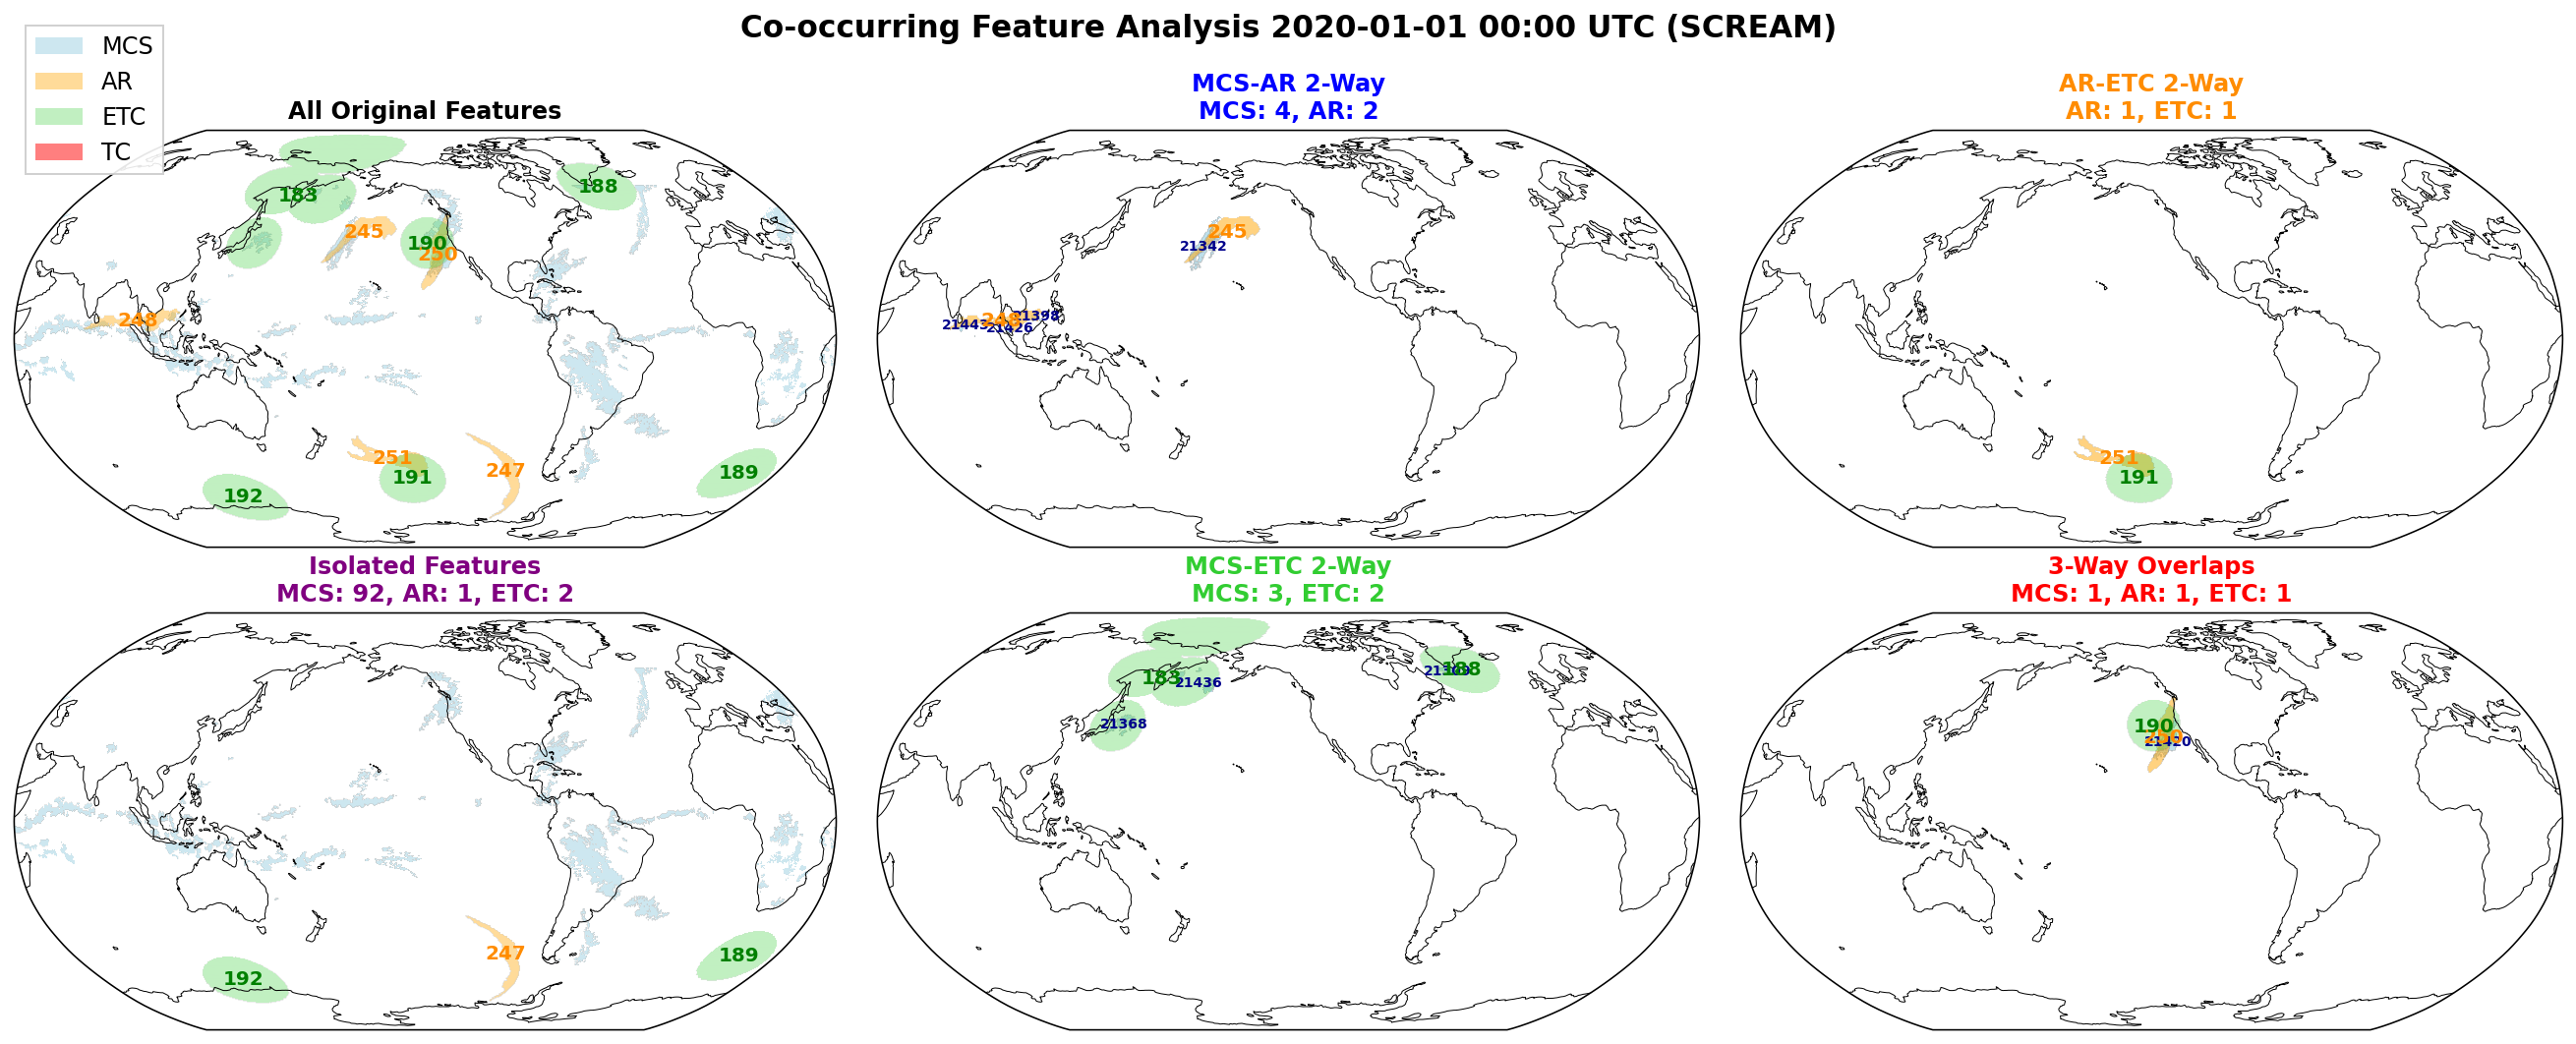

In [13]:
# CREATE COMPREHENSIVE 6-PANEL VISUALIZATION
print("🚀 CREATING COMPREHENSIVE 6-PANEL VISUALIZATION")
print("="*55)

time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
datetime_string = _time.dt.strftime('%Y%m%d_%H%M').item()
suptitle = f"Co-occurring Feature Analysis {time_label} ({source_name.upper()})"
figname = f"{figdir}{source_name}_cofmasks_6panel_horizontal_{datetime_string}.png"

# Call the comprehensive visualization function
fig_6panel = plot_6panel_horizontal(
    ds=_ds,
    figname=figname,
    suptitle=suptitle,
)

In [19]:
def create_union_mask(mask_list):
    """
    Create a union mask from multiple mask variables.
    
    The union operation is applied on the spatial (cell) dimension only, 
    preserving any time or other dimensions in the input masks.
    
    Parameters:
    -----------
    mask_list : list of xarray.DataArray
        List of mask DataArrays to combine. Each mask can contain track IDs (integers > 0)
        or binary values (0 or 1). Masks will be converted to binary before combining.
        All masks should have the same dimensions (e.g., time and cell).
    
    Returns:
    --------
    xarray.DataArray
        Binary mask (0 or 1 as float) representing the union of all input masks.
        A pixel is 1 if it appears in any of the input masks at that time, 0 otherwise.
        The output preserves all dimensions from the input (e.g., time, cell).
    
    Example:
    --------
    >>> # Create union of 3-way overlap masks (with time dimension)
    >>> union_mask = create_union_mask([
    ...     ds.mcs_ar_etc_overlap_mask,  # shape: (time: 3138, cell: 786432)
    ...     ds.ar_mcs_etc_overlap_mask,
    ...     ds.etc_mcs_ar_overlap_mask
    ... ])
    >>> # Result shape: (time: 3138, cell: 786432)
    
    >>> # Create union for single timestep
    >>> union_mask_single = create_union_mask([
    ...     ds.mcs_ar_overlap_mask.sel(time='2020-01-01'),
    ...     ds.ar_etc_overlap_mask.sel(time='2020-01-01')
    ... ])
    
    >>> # Create union of all 2-way overlaps over time range
    >>> all_2way = create_union_mask([
    ...     ds.mcs_ar_overlap_mask.sel(time=slice('2020-01', '2020-02')),
    ...     ds.ar_etc_overlap_mask.sel(time=slice('2020-01', '2020-02')),
    ...     ds.mcs_etc_overlap_mask.sel(time=slice('2020-01', '2020-02'))
    ... ])
    """
    if not mask_list:
        raise ValueError("mask_list cannot be empty")
    
    # Convert each mask to binary (any value > 0 becomes 1)
    # This operation preserves all dimensions (time, cell, etc.)
    binary_masks = [(mask > 0).astype(float) for mask in mask_list]
    
    # Sum all binary masks element-wise across all dimensions
    # This maintains the shape (e.g., time x cell)
    summed_mask = sum(binary_masks)
    
    # Convert back to binary (any sum > 0 becomes 1)
    # Union at each time step: a cell is 1 if it appears in ANY mask at that time
    union_mask = (summed_mask > 0).astype(float)
    
    return union_mask

print("✅ create_union_mask() function defined")

✅ create_union_mask() function defined


In [26]:
_ds

<xarray.Dataset> Size: 69MB
Dimensions:                  (cell: 786432)
Coordinates:
    time                     datetime64[ns] 8B 2020-01-01
    crs                      int64 8B 0
  * cell                     (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
    lat                      (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                      (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
Data variables: (12/16)
    ar_etc_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_isolated_mask         (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mask                  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mcs_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    etc_ar_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ...                       ...
    mcs_ar_etc_overlap_mask  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_ar_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_etc_overlap_mask     (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_isolated_mask        (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_mask                 (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    tc_mask                  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
Attributes: (12/45)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tc_filtering_threshold:       10%
    threads_per_worker:           2
    thresholds:                   MCS: 20%, AR: 10%, ETC: 5% (2-way), 0% (3-way)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [40]:
# Create union of 2-way overlap masks using the general function
mcs_ar_2way_mask = create_union_mask([
    _ds.mcs_ar_overlap_mask,
    _ds.ar_mcs_overlap_mask,
])

mcs_etc_2way_mask = create_union_mask([
    _ds.mcs_etc_overlap_mask,
    _ds.etc_mcs_overlap_mask,
])

ar_etc_2way_mask = create_union_mask([
    _ds.ar_etc_overlap_mask,
    _ds.etc_ar_overlap_mask,
])

# Create union of 3-way overlap masks using the general function
mcs_ar_etc_3way_mask = create_union_mask([
    _ds.mcs_ar_etc_overlap_mask,
    _ds.ar_mcs_etc_overlap_mask,
    _ds.etc_mcs_ar_overlap_mask
])

# Isolated masks
mcs_iso_mask = _ds.mcs_isolated_mask > 0
ar_iso_mask = _ds.ar_isolated_mask > 0
etc_iso_mask = _ds.etc_isolated_mask > 0

<Figure size 921.6x691.2 with 0 Axes>

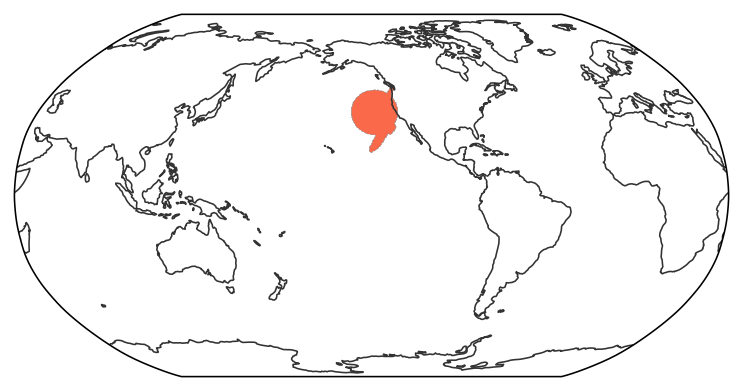

In [42]:
egh.healpix_show(mcs_ar_etc_3way_mask.where(mcs_ar_etc_3way_mask > 0), cmap='Reds', vmin=0.5, vmax=1.5)
# tmp = _ds.etc_mcs_ar_overlap_mask
# egh.healpix_show(tmp.where(tmp > 0), cmap='Reds', vmin=0.5, vmax=1.5)
# mcs_ar_etc_3way_mask

In [51]:
def plot_7panel_combined_masks(mcs_iso, ar_iso, etc_iso, 
                               mcs_ar_2way, mcs_etc_2way, ar_etc_2way, 
                               mcs_ar_etc_3way,
                               figname=None, suptitle="", dpi=200):
    """
    Create a 7-panel visualization showing all combined overlap masks.
    
    Layout (2 rows x 4 columns, last position empty):
    Row 1: Isolated MCS, Isolated AR, Isolated ETC, MCS-AR 2-way
    Row 2: MCS-ETC 2-way, AR-ETC 2-way, 3-way overlaps, [empty]
    
    Parameters:
    -----------
    mcs_iso, ar_iso, etc_iso : xarray.DataArray
        Binary masks for isolated features (single timestep)
    mcs_ar_2way, mcs_etc_2way, ar_etc_2way : xarray.DataArray
        Binary union masks for 2-way overlaps (single timestep)
    mcs_ar_etc_3way : xarray.DataArray
        Binary union mask for 3-way overlaps (single timestep)
    figname : str, optional
        Filename to save figure
    suptitle : str, optional
        Super title for the entire figure
    dpi : int, optional
        DPI for figure display and saving (default 200)
    
    Returns:
    --------
    matplotlib.figure.Figure
    """
    print("🎨 Creating 7-panel combined masks visualization...")
    
    # Define colors for each panel
    colors = {
        'mcs_iso': 'lightblue',
        'ar_iso': 'orange',
        'etc_iso': 'limegreen',
        'mcs_ar': 'mediumpurple',
        'mcs_etc': 'deepskyblue',
        'ar_etc': 'gold',
        '3way': 'crimson'
    }
    
    title_fontsize = 12
    
    # Create figure with GridSpec (2 rows x 4 columns)
    fig = plt.figure(figsize=(20, 7))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], width_ratios=[1, 1, 1, 1],
                          hspace=0.12, wspace=0.05, top=0.88, bottom=0.05, 
                          left=0.03, right=0.97)
    
    # Figure suptitle
    fig.suptitle(suptitle, fontsize=title_fontsize*1.4, fontweight='bold', y=0.95)
    
    # Create projection for all axes
    projection = ccrs.Robinson(central_longitude=-135)
    
    # Row 0: Isolated features + MCS-AR 2-way
    ax_mcs_iso = fig.add_subplot(gs[0, 0], projection=projection)
    ax_ar_iso = fig.add_subplot(gs[0, 1], projection=projection)
    ax_etc_iso = fig.add_subplot(gs[0, 2], projection=projection)
    ax_mcs_ar = fig.add_subplot(gs[0, 3], projection=projection)
    
    # Row 1: 2-way overlaps + 3-way
    ax_mcs_etc = fig.add_subplot(gs[1, 0], projection=projection)
    ax_ar_etc = fig.add_subplot(gs[1, 1], projection=projection)
    ax_3way = fig.add_subplot(gs[1, 2], projection=projection)
    
    # Configure all axes
    all_axes = [ax_mcs_iso, ax_ar_iso, ax_etc_iso, ax_mcs_ar, 
                ax_mcs_etc, ax_ar_etc, ax_3way]
    for ax in all_axes:
        ax.set_global()
        ax.add_feature(cf.COASTLINE, linewidth=0.5)
    
    # ==== PANEL 1: ISOLATED MCS ====
    print("  📍 Panel 1: Isolated MCS")
    if np.any(mcs_iso > 0):
        egh.healpix_show(mcs_iso.where(mcs_iso > 0), ax=ax_mcs_iso,
                        cmap=mpl.colors.ListedColormap([colors['mcs_iso']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_mcs_iso = int(mcs_iso.sum().values)
    ax_mcs_iso.set_title(f"Isolated MCS\n({n_mcs_iso:,} pixels)",
                         fontsize=title_fontsize, fontweight='bold', color='darkblue')
    
    # ==== PANEL 2: ISOLATED AR ====
    print("  📍 Panel 2: Isolated AR")
    if np.any(ar_iso > 0):
        egh.healpix_show(ar_iso.where(ar_iso > 0), ax=ax_ar_iso,
                        cmap=mpl.colors.ListedColormap([colors['ar_iso']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_ar_iso = int(ar_iso.sum().values)
    ax_ar_iso.set_title(f"Isolated AR\n({n_ar_iso:,} pixels)",
                        fontsize=title_fontsize, fontweight='bold', color='darkorange')
    
    # ==== PANEL 3: ISOLATED ETC ====
    print("  📍 Panel 3: Isolated ETC")
    if np.any(etc_iso > 0):
        egh.healpix_show(etc_iso.where(etc_iso > 0), ax=ax_etc_iso,
                        cmap=mpl.colors.ListedColormap([colors['etc_iso']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_etc_iso = int(etc_iso.sum().values)
    ax_etc_iso.set_title(f"Isolated ETC\n({n_etc_iso:,} pixels)",
                         fontsize=title_fontsize, fontweight='bold', color='green')
    
    # ==== PANEL 4: MCS-AR 2-WAY ====
    print("  📍 Panel 4: MCS-AR 2-way overlaps")
    if np.any(mcs_ar_2way > 0):
        egh.healpix_show(mcs_ar_2way.where(mcs_ar_2way > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([colors['mcs_ar']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_mcs_ar = int(mcs_ar_2way.sum().values)
    ax_mcs_ar.set_title(f"MCS-AR 2-Way\n({n_mcs_ar:,} pixels)",
                        fontsize=title_fontsize, fontweight='bold', color='purple')
    
    # ==== PANEL 5: MCS-ETC 2-WAY ====
    print("  📍 Panel 5: MCS-ETC 2-way overlaps")
    if np.any(mcs_etc_2way > 0):
        egh.healpix_show(mcs_etc_2way.where(mcs_etc_2way > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([colors['mcs_etc']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_mcs_etc = int(mcs_etc_2way.sum().values)
    ax_mcs_etc.set_title(f"MCS-ETC 2-Way\n({n_mcs_etc:,} pixels)",
                         fontsize=title_fontsize, fontweight='bold', color='teal')
    
    # ==== PANEL 6: AR-ETC 2-WAY ====
    print("  📍 Panel 6: AR-ETC 2-way overlaps")
    if np.any(ar_etc_2way > 0):
        egh.healpix_show(ar_etc_2way.where(ar_etc_2way > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([colors['ar_etc']]), 
                        alpha=0.8, vmin=0.5, vmax=1.5)
    n_ar_etc = int(ar_etc_2way.sum().values)
    ax_ar_etc.set_title(f"AR-ETC 2-Way\n({n_ar_etc:,} pixels)",
                        fontsize=title_fontsize, fontweight='bold', color='darkgoldenrod')
    
    # ==== PANEL 7: 3-WAY OVERLAPS ====
    print("  📍 Panel 7: 3-way overlaps")
    if np.any(mcs_ar_etc_3way > 0):
        egh.healpix_show(mcs_ar_etc_3way.where(mcs_ar_etc_3way > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([colors['3way']]), 
                        alpha=0.9, vmin=0.5, vmax=1.5)
    n_3way = int(mcs_ar_etc_3way.sum().values)
    ax_3way.set_title(f"3-Way Overlaps\n({n_3way:,} pixels)",
                      fontsize=title_fontsize, fontweight='bold', color='darkred')
    
    # Create invisible axis for legend positioning (row 1, column 3 - the empty spot)
    ax_legend = fig.add_subplot(gs[1, 3])
    ax_legend.axis('off')  # Make it invisible
    
    # Add legend anchored to the center top of the empty axis
    legend_elements = [
        Patch(facecolor=colors['mcs_iso'], label='Isolated MCS'),
        Patch(facecolor=colors['ar_iso'], label='Isolated AR'),
        Patch(facecolor=colors['etc_iso'], label='Isolated ETC'),
        Patch(facecolor=colors['mcs_ar'], label='MCS-AR 2-way'),
        Patch(facecolor=colors['mcs_etc'], label='MCS-ETC 2-way'),
        Patch(facecolor=colors['ar_etc'], label='AR-ETC 2-way'),
        Patch(facecolor=colors['3way'], label='3-way')
    ]
    ax_legend.legend(handles=legend_elements, 
                    loc='upper center', 
                    fontsize=11, framealpha=0.95, fancybox=True, shadow=True,
                    title='Feature Types', title_fontsize=12)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"✅ 7-panel combined masks visualization saved: {figname}")
    
    return fig

print("✅ plot_7panel_combined_masks() function defined")

✅ plot_7panel_combined_masks() function defined


🚀 CREATING 7-PANEL COMBINED MASKS VISUALIZATION
🎨 Creating 7-panel combined masks visualization...
  📍 Panel 1: Isolated MCS
  📍 Panel 2: Isolated AR
  📍 Panel 2: Isolated AR
  📍 Panel 3: Isolated ETC
  📍 Panel 3: Isolated ETC
  📍 Panel 4: MCS-AR 2-way overlaps
  📍 Panel 4: MCS-AR 2-way overlaps
  📍 Panel 5: MCS-ETC 2-way overlaps
  📍 Panel 5: MCS-ETC 2-way overlaps
  📍 Panel 6: AR-ETC 2-way overlaps
  📍 Panel 6: AR-ETC 2-way overlaps
  📍 Panel 7: 3-way overlaps
  📍 Panel 7: 3-way overlaps
✅ 7-panel combined masks visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_combined_masks_7panel_20200101_0000.png
✅ 7-panel combined masks visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/scream_combined_masks_7panel_20200101_0000.png


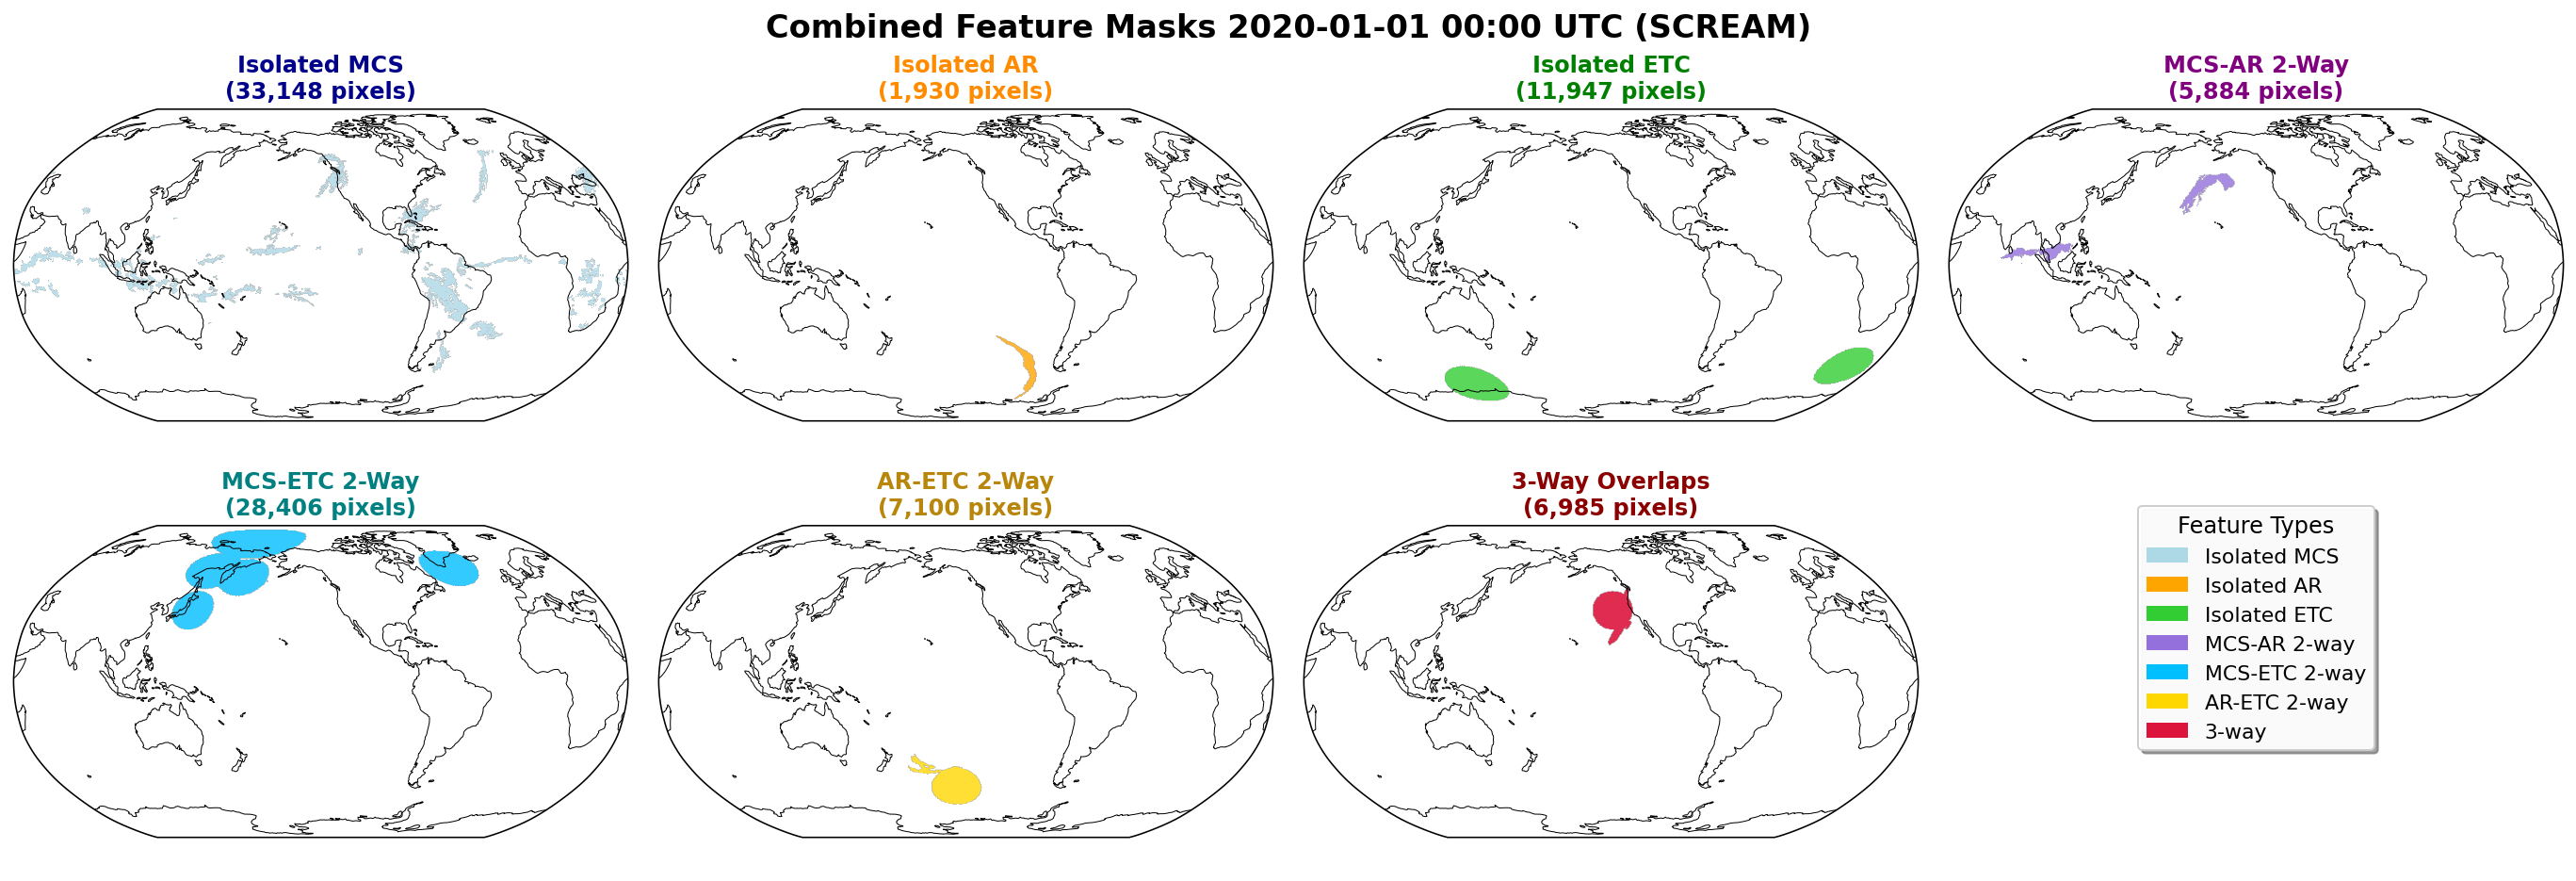

In [52]:
# CREATE 7-PANEL COMBINED MASKS VISUALIZATION
print("🚀 CREATING 7-PANEL COMBINED MASKS VISUALIZATION")
print("="*60)

time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
datetime_string = _time.dt.strftime('%Y%m%d_%H%M').item()
suptitle = f"Combined Feature Masks {time_label} ({source_name.upper()})"
figname = f"{figdir}{source_name}_combined_masks_7panel_{datetime_string}.png"

# Call the 7-panel visualization function
fig_7panel = plot_7panel_combined_masks(
    mcs_iso=mcs_iso_mask,
    ar_iso=ar_iso_mask,
    etc_iso=etc_iso_mask,
    mcs_ar_2way=mcs_ar_2way_mask,
    mcs_etc_2way=mcs_etc_2way_mask,
    ar_etc_2way=ar_etc_2way_mask,
    mcs_ar_etc_3way=mcs_ar_etc_3way_mask,
    figname=figname,
    suptitle=suptitle,
    dpi=200
)

plt.show()

In [53]:
# # Example: Create union of 3-way overlap masks using the general function
# mcs_ar_etc_3way_mask = create_union_mask([
#     _ds.mcs_ar_etc_overlap_mask,
#     _ds.ar_mcs_etc_overlap_mask,
#     _ds.etc_mcs_ar_overlap_mask
# ])

# egh.healpix_show(mcs_ar_etc_3way_mask)

# # Original code (commented out for reference):
# # # Convert overlap masks to binary
# # mcs_ar_etc_overlap_mask = (_ds.mcs_ar_etc_overlap_mask > 0).astype(float)
# # ar_mcs_etc_overlap_mask = (_ds.ar_mcs_etc_overlap_mask > 0).astype(float)
# # etc_mcs_ar_overlap_mask = (_ds.etc_mcs_ar_overlap_mask > 0).astype(float)
# # # Sum the binary masks to identify 3-way overlaps
# # mcs_ar_etc_3way_mask = ((mcs_ar_etc_overlap_mask + ar_mcs_etc_overlap_mask + etc_mcs_ar_overlap_mask) > 0).astype(float)

In [54]:
# mcs_ar_etc_3way_mask = create_union_mask([
#     ds.mcs_ar_etc_overlap_mask.sel(time=slice('2020-01-01', '2020-01-02')),
#     ds.ar_mcs_etc_overlap_mask.sel(time=slice('2020-01-01', '2020-01-02')),
#     ds.etc_mcs_ar_overlap_mask.sel(time=slice('2020-01-01', '2020-01-02')),
# ])

# # mcs_ar_etc_3way_mask
# egh.healpix_show(mcs_ar_etc_3way_mask.isel(time=4))

In [ ]:
sdate = '2020-01-01T00'
edate = '2020-01-31T23'
# sdate = '2020-07-01T00'
# edate = '2020-07-31T23'
# sdate = '2019-08-01T00'
# edate = '2020-08-31T23'

# Use the general function to create union of 3-way overlaps
mcs_ar_etc_3way_mask = create_union_mask([
    ds.mcs_ar_etc_overlap_mask.sel(time=slice(sdate, edate)),
    ds.ar_mcs_etc_overlap_mask.sel(time=slice(sdate, edate)),
    ds.etc_mcs_ar_overlap_mask.sel(time=slice(sdate, edate))
])

# Count occurrences over time
mcs_ar_etc_3way_counts = mcs_ar_etc_3way_mask.sum(dim='time')

<Figure size 921.6x691.2 with 0 Axes>

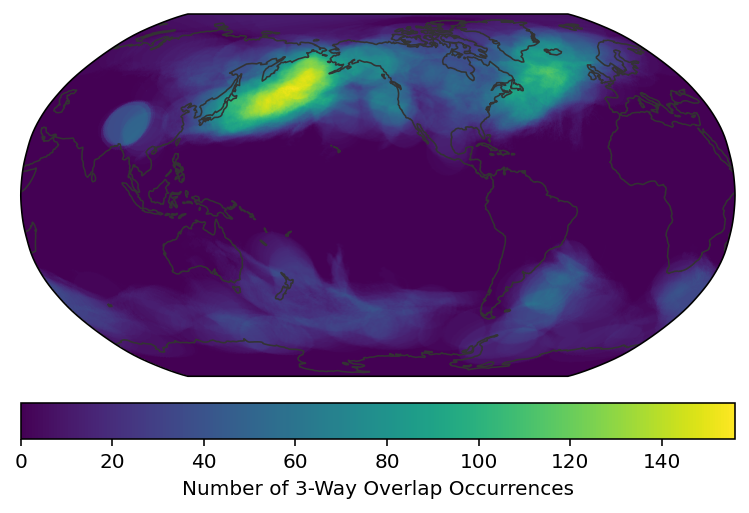

In [25]:
im = egh.healpix_show(mcs_ar_etc_3way_counts)
plt.colorbar(im, label='Number of 3-Way Overlap Occurrences', orientation='horizontal', pad=0.05)